#1 Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#2 Upload cleaned data

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_customer_transactions.csv to cleaned_customer_transactions.csv


#3 Load dataset

In [7]:
import pandas as pd
df = pd.read_csv("cleaned_customer_transactions.csv")
display(df.head())

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,DiscountPercent,Revenue,ProductCategory,Country,Region,AcquisitionChannel,SubscriptionPlan,OrderStatus,PaymentMethod,TransactionMonth,CohortMonth,CohortIndex
0,INV100002,C00001,2026-01-05,3,167.05,15,425.9775,Education,India,East,Organic Search,Basic,Completed,Net Banking,2026-01-01,2026-01-01,1
1,INV100003,C00001,2026-01-01,4,477.13,15,1622.2420,Software,India,East,Organic Search,Basic,Completed,Debit Card,2026-01-01,2026-01-01,1
2,INV100004,C00002,2026-02-06,1,562.38,5,534.2610,Books,United Kingdom,North,Referral,Basic,Completed,UPI,2026-02-01,2026-02-01,1
3,INV100005,C00002,2026-02-08,2,558.93,0,1117.8600,Books,United Kingdom,North,Referral,Basic,Completed,Debit Card,2026-02-01,2026-02-01,1
4,INV100006,C00002,2026-03-06,2,177.19,0,354.3800,Fashion,United Kingdom,North,Referral,Basic,Completed,UPI,2026-03-01,2026-02-01,2


#4 Convert the date column

In [8]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

if "TransactionMonth" in df.columns:
    df["TransactionMonth"] = pd.to_datetime(
        df["TransactionMonth"],
        errors="coerce"
    )

if "CohortMonth" in df.columns:
    df["CohortMonth"] = pd.to_datetime(
        df["CohortMonth"],
        errors="coerce"
    )

#5 Validate columns

In [9]:
required_columns = [
    "CustomerID",
    "InvoiceNo",
    "InvoiceDate",
    "Revenue",
    "Quantity",
    "Country",
    "Region",
    "AcquisitionChannel",
    "SubscriptionPlan"
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Validation passed.")

Validation passed.


#6 Create customer-level table

In [10]:
customer = (
    df.groupby("CustomerID")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        Country=("Country", "first"),
        Region=("Region", "first"),
        AcquisitionChannel=("AcquisitionChannel", "first"),
        SubscriptionPlan=("SubscriptionPlan", "first")
    )
    .reset_index()
)

display(customer.head())

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,Country,Region,AcquisitionChannel,SubscriptionPlan
0,C00001,2048.2195,2,7,2026-01-01,2026-01-05,India,East,Organic Search,Basic
1,C00002,3127.6170,4,7,2026-02-06,2026-03-26,United Kingdom,North,Referral,Basic
2,C00003,22259.3860,7,22,2025-05-19,2025-09-23,United Kingdom,North,Social Media,Standard
3,C00004,10300.8000,1,5,2025-08-06,2025-08-06,India,Central,Organic Search,Premium
4,C00005,900.2240,1,4,2025-03-30,2025-03-30,India,East,Email,Basic


#7 Average Order Value

In [11]:
customer["AverageOrderValue"] = (
    customer["TotalRevenue"]
    / customer["TotalOrders"]
).round(2)

#8 Customer Lifespan

In [12]:
customer["CustomerLifespanDays"] = (
    customer["LastPurchase"]
    - customer["FirstPurchase"]
).dt.days

In [13]:
customer["CustomerLifespanMonths"] = (
    customer["CustomerLifespanDays"] / 30.44
)

customer["CustomerLifespanMonths"] = (
    customer["CustomerLifespanMonths"]
    .clip(lower=1)
    .round(2)
)

#9 Purchase Frequency

In [14]:
customer["PurchaseFrequencyPerMonth"] = (
    customer["TotalOrders"]
    / customer["CustomerLifespanMonths"]
).round(2)

#10 Historical CLTV

In [15]:
customer["HistoricalCLTV"] = (
    customer["AverageOrderValue"]
    * customer["PurchaseFrequencyPerMonth"]
    * customer["CustomerLifespanMonths"]
).round(2)

#11 Compare CLTV with revenue

In [16]:
customer["CLTVDifference"] = (
    customer["HistoricalCLTV"]
    - customer["TotalRevenue"]
).round(2)

display(
    customer[
        [
            "CustomerID",
            "TotalRevenue",
            "HistoricalCLTV",
            "CLTVDifference"
        ]
    ].head(10)
)

,CustomerID,TotalRevenue,HistoricalCLTV,CLTVDifference
0,C00001,2048.2195,2048.22,0.00
1,C00002,3127.6170,3125.57,-2.05
2,C00003,22259.3860,22277.18,17.79
3,C00004,10300.8000,10300.80,0.00
4,C00005,900.2240,900.22,-0.00
5,C00006,2345.0880,2340.88,-4.21
6,C00007,76814.0640,77059.91,245.85
7,C00008,2672.1215,2665.44,-6.68
8,C00009,120106.2630,119770.02,-336.24
9,C00010,10711.7085,10711.70,-0.01


#12 Create CLTV segments

In [17]:
customer["CLTVSegment"] = pd.qcut(
    customer["HistoricalCLTV"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Very High Value"
    ]
)

print(customer["CLTVSegment"].value_counts())

CLTVSegment
Low Value          290
Medium Value       289
High Value         289
Very High Value    289
Name: count, dtype: int64


#13 Segment sort order

In [18]:
segment_order = {
    "Low Value": 1,
    "Medium Value": 2,
    "High Value": 3,
    "Very High Value": 4
}

customer["CLTVSegmentSort"] = (
    customer["CLTVSegment"]
    .astype(str)
    .map(segment_order)
)

#14 Build final CustomerCLTV table

In [19]:
display(customer.head())

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,Country,Region,AcquisitionChannel,SubscriptionPlan,AverageOrderValue,CustomerLifespanDays,CustomerLifespanMonths,PurchaseFrequencyPerMonth,HistoricalCLTV,CLTVDifference,CLTVSegment,CLTVSegmentSort
0,C00001,2048.2195,2,7,2026-01-01,2026-01-05,India,East,Organic Search,Basic,1024.11,4,1.00,2.00,2048.22,0.00,Low Value,1
1,C00002,3127.6170,4,7,2026-02-06,2026-03-26,United Kingdom,North,Referral,Basic,781.90,48,1.58,2.53,3125.57,-2.05,Medium Value,2
2,C00003,22259.3860,7,22,2025-05-19,2025-09-23,United Kingdom,North,Social Media,Standard,3179.91,127,4.17,1.68,22277.18,17.79,Very High Value,4
3,C00004,10300.8000,1,5,2025-08-06,2025-08-06,India,Central,Organic Search,Premium,10300.80,0,1.00,1.00,10300.80,0.00,High Value,3
4,C00005,900.2240,1,4,2025-03-30,2025-03-30,India,East,Email,Basic,900.22,0,1.00,1.00,900.22,-0.00,Low Value,1


#15 CLTV KPI summary

In [20]:
cltv_summary = pd.DataFrame({
    "Metric": [
        "Customers",
        "Average Historical CLTV",
        "Median Historical CLTV",
        "Maximum Historical CLTV",
        "Average Customer Lifespan (Months)",
        "Average Purchase Frequency / Month",
        "Average Order Value"
    ],
    "Value": [
        customer["CustomerID"].nunique(),
        round(customer["HistoricalCLTV"].mean(), 2),
        round(customer["HistoricalCLTV"].median(), 2),
        round(customer["HistoricalCLTV"].max(), 2),
        round(customer["CustomerLifespanMonths"].mean(), 2),
        round(customer["PurchaseFrequencyPerMonth"].mean(), 2),
        round(customer["AverageOrderValue"].mean(), 2)
    ]
})

display(cltv_summary)

,Metric,Value
0,Customers,1157.00
1,Average Historical CLTV,11095.58
2,Median Historical CLTV,4860.02
3,Maximum Historical CLTV,125369.87
4,Average Customer Lifespan (Months),1.96
5,Average Purchase Frequency / Month,1.66
6,Average Order Value,3088.47


#16 CLTV distribution

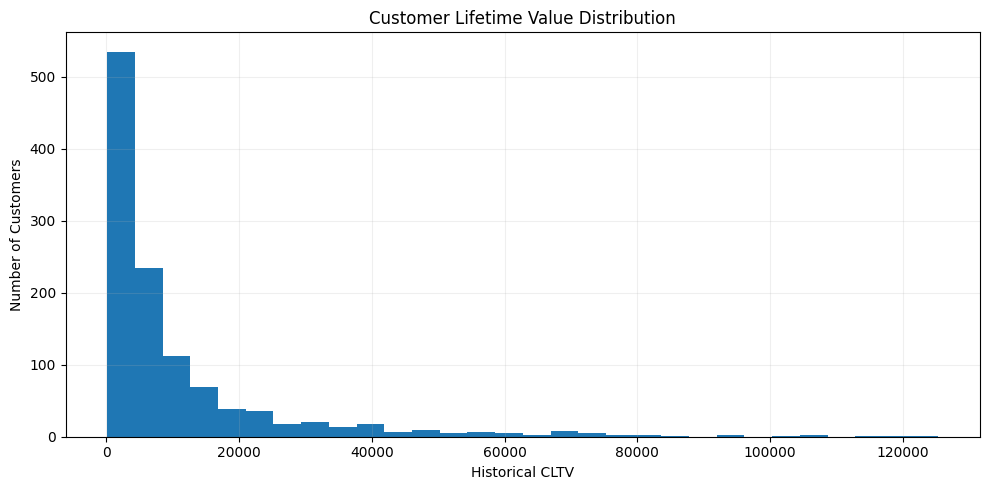

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer["HistoricalCLTV"],
    bins=30
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Historical CLTV")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

#17 CLTV Segment Profile

In [22]:
segment_profile = (
    customer.groupby(
        "CLTVSegment",
        observed=False
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        AverageCLTV=("HistoricalCLTV", "mean"),
        TotalCLTV=("HistoricalCLTV", "sum"),
        AverageOrders=("TotalOrders", "mean"),
        AverageOrderValue=("AverageOrderValue", "mean"),
        AverageLifespanMonths=("CustomerLifespanMonths", "mean"),
        AveragePurchaseFrequency=("PurchaseFrequencyPerMonth", "mean")
    )
    .reset_index()
)

#18 Top 10 Customers

In [23]:
top_10_customers = (
    customer.sort_values(
        "HistoricalCLTV",
        ascending=False
    )
    .head(10)
)

display(top_10_customers)

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,Country,Region,AcquisitionChannel,SubscriptionPlan,AverageOrderValue,CustomerLifespanDays,CustomerLifespanMonths,PurchaseFrequencyPerMonth,HistoricalCLTV,CLTVDifference,CLTVSegment,CLTVSegmentSort
161,C00168,125359.1980,13,41,2025-10-10,2026-06-29,Australia,West,Organic Search,Premium,9643.02,262,8.61,1.51,125369.87,10.67,Very High Value,4
8,C00009,120106.2630,12,42,2025-02-09,2025-10-20,United States,South,Organic Search,Premium,10008.86,253,8.31,1.44,119770.02,-336.24,Very High Value,4
1029,C01067,113938.7415,11,32,2025-05-17,2026-02-04,India,Central,Organic Search,Premium,10358.07,263,8.64,1.27,113657.03,-281.71,Very High Value,4
836,C00871,107689.9185,10,34,2026-01-08,2026-06-01,United States,North,Organic Search,Premium,10768.99,144,4.73,2.11,107477.75,-212.17,Very High Value,4
449,C00473,107611.6510,13,40,2025-07-23,2026-03-15,India,Central,Referral,Premium,8277.82,235,7.72,1.68,107360.01,-251.64,Very High Value,4
833,C00868,105341.2880,7,30,2025-07-03,2025-11-03,India,West,Paid Search,Premium,15048.76,123,4.04,1.73,105178.79,-162.50,Very High Value,4
65,C00071,102011.9505,14,37,2025-10-20,2026-06-07,United States,Central,Affiliate,Premium,7286.57,230,7.56,1.85,101909.97,-101.98,Very High Value,4
526,C00552,93395.2890,9,27,2025-04-10,2025-10-09,United States,West,Referral,Premium,10377.25,182,5.98,1.51,93704.49,309.20,Very High Value,4
76,C00082,93594.4495,11,33,2025-04-01,2025-12-20,Canada,North,Email,Premium,8508.59,263,8.64,1.27,93363.06,-231.39,Very High Value,4
1040,C01079,92456.8030,11,32,2025-11-29,2026-06-12,India,North,Referral,Premium,8405.16,195,6.41,1.72,92668.57,211.77,Very High Value,4


#19 Export CustomerCLTV

In [24]:
customer.to_csv(
    "customer_cltv.csv",
    index=False
)

#20 Download main file

In [25]:
from google.colab import files

files.download("customer_cltv.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>